## XG Boost Regression

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score, mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance
import xgboost as xgb
from xgboost import XGBRegressor
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

RANDOM_STATE = 42
DATA_PATH = "data/telco-churn.csv"
TARGET = "MonthlyCharges"
USE_TOTAL_CHARGES = False 

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### Load and inspect the data 

In [2]:
df = pd.read_csv(DATA_PATH)
print("Rows, columns:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Rows, columns: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


In [3]:
df.sample(10, random_state=RANDOM_STATE)   # random rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.8000,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.2500,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.3500,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.3500,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.5500,3260.1,No
1263,6818-WOBHJ,Female,1,Yes,No,68,Yes,Yes,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),89.6000,6127.6,Yes
3732,3082-YVEKW,Female,0,Yes,Yes,23,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),77.1500,1759.4,No
1672,4737-AQCPU,Male,0,Yes,Yes,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,No,No,Two year,No,Credit card (automatic),72.1000,5016.65,No
811,4853-RULSV,Male,0,No,No,70,Yes,Yes,Fiber optic,Yes,No,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),104.0000,7250.15,Yes
2526,5766-ZJYBB,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.4000,19.4,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,"7,043.0000",NaN,NaN,NaN,0.1621,0.3686,0.0000,0.0000,0.0000,0.0000,1.0000
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,"7,043.0000",NaN,NaN,NaN,32.3711,24.5595,0.0000,9.0000,29.0000,55.0000,72.0000
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Blank / invalid TotalCharges rows:", df["TotalCharges"].isna().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"])

print("Total missing values after cleaning:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

Blank / invalid TotalCharges rows: 11
Total missing values after cleaning: 0
Duplicate rows: 0


## Exploratory data analysis (EDA)

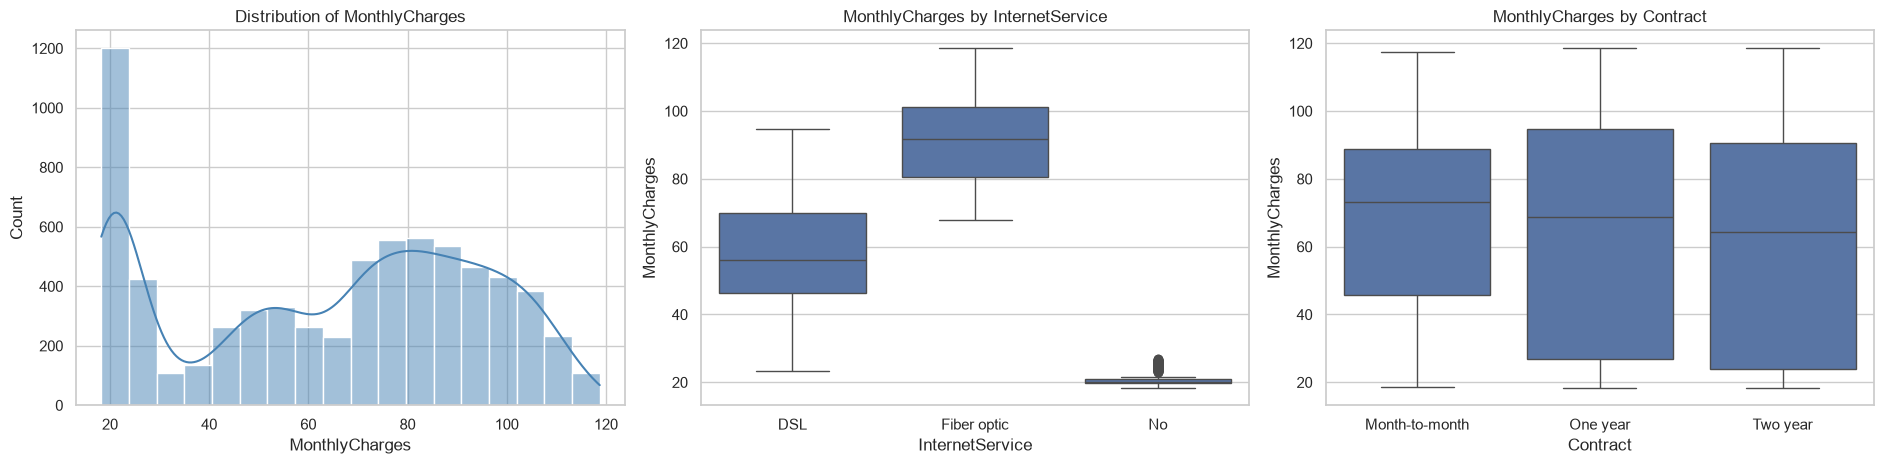

count   7,043.0000
mean       64.7617
std        30.0900
min        18.2500
25%        35.5000
50%        70.3500
75%        89.8500
max       118.7500
Name: MonthlyCharges, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
sns.histplot(df[TARGET], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of MonthlyCharges")
sns.boxplot(data=df, x="InternetService", y=TARGET, ax=axes[1])
axes[1].set_title("MonthlyCharges by InternetService")
sns.boxplot(data=df, x="Contract", y=TARGET, ax=axes[2])
axes[2].set_title("MonthlyCharges by Contract")
plt.tight_layout()
plt.show()

print(df[TARGET].describe())

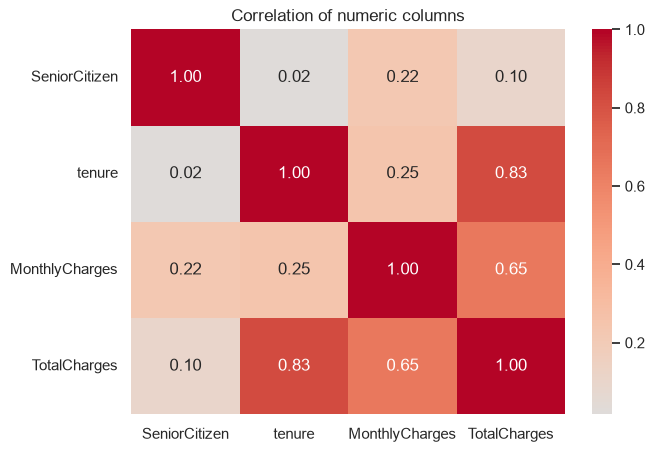

corr(TotalCharges, tenure x MonthlyCharges) = 0.9996


In [8]:
numeric_raw = df.select_dtypes(include="number")
plt.figure(figsize=(7, 5))
sns.heatmap(numeric_raw.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation of numeric columns")
plt.show()

# Is TotalCharges basically the target in disguise?
leak_corr = np.corrcoef(df["TotalCharges"], df["tenure"] * df["MonthlyCharges"])[0, 1]
print(f"corr(TotalCharges, tenure x MonthlyCharges) = {leak_corr:.4f}")

## Feature Engineering

In [9]:
def engineer_features(data):
    d = data.copy()
    d = d.drop(columns=["customerID"], errors="ignore")

    #Harmonise duplicate labels
    addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection","TechSupport", "StreamingTV", "StreamingMovies"]
    d[addon_cols] = d[addon_cols].replace("No internet service", "No")
    d["MultipleLines"] = d["MultipleLines"].replace("No phone service", "No")

    # Counts
    d["num_addons"] = (d[addon_cols] == "Yes").sum(axis=1)
    d["num_streaming"] = (d[["StreamingTV", "StreamingMovies"]] == "Yes").sum(axis=1)
    d["num_protection"] = (d[["OnlineSecurity", "OnlineBackup","DeviceProtection", "TechSupport"]] == "Yes").sum(axis=1)

    # Binary flags
    d["has_internet"] = (d["InternetService"] != "No").astype(int)
    d["is_fiber"] = (d["InternetService"] == "Fiber optic").astype(int)
    d["has_phone"] = (d["PhoneService"] == "Yes").astype(int)
    d["multiple_lines_flag"] = (d["MultipleLines"] == "Yes").astype(int)
    d["total_services"] = (d["num_addons"] + d["has_internet"]+ d["has_phone"] + d["multiple_lines_flag"])
    d["auto_pay"] = d["PaymentMethod"].str.contains("automatic", case=False).astype(int)
    d["is_month_to_month"] = (d["Contract"] == "Month-to-month").astype(int)
    d["has_family"] = ((d["Partner"] == "Yes") | (d["Dependents"] == "Yes")).astype(int)

    #Tenure transformations
    d["log_tenure"] = np.log1p(d["tenure"])
    d["tenure_sq"] = d["tenure"] ** 2
    d["tenure_group"] = pd.cut(d["tenure"], bins=[-1, 12, 24, 48, 60, np.inf],
    labels=["0-12", "13-24", "25-48", "49-60", "61+"]).astype(str)

    #  Leakage control
    if not USE_TOTAL_CHARGES:
        d = d.drop(columns=["TotalCharges"], errors="ignore")
    return d


X_all = engineer_features(df.drop(columns=[TARGET]))
y = df[TARGET]
print("Feature matrix shape:", X_all.shape)
X_all.head()

Feature matrix shape: (7043, 32)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,num_addons,num_streaming,num_protection,has_internet,is_fiber,has_phone,multiple_lines_flag,total_services,auto_pay,is_month_to_month,has_family,log_tenure,tenure_sq,tenure_group
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No,1,0,1,1,0,0,0,2,0,1,1,0.6931,1,0-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No,2,0,2,1,0,1,0,4,0,0,0,3.5553,1156,25-48
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes,2,0,2,1,0,1,0,4,0,1,0,1.0986,4,0-12
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No,3,0,3,1,0,0,0,4,1,0,0,3.8286,2025,25-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes,0,0,0,1,1,1,0,2,0,1,0,1.0986,4,0-12


In [10]:
new_feats = ["num_addons", "num_streaming", "num_protection", "total_services","has_internet", "is_fiber", "has_phone", "multiple_lines_flag",
"auto_pay", "is_month_to_month", "has_family", "log_tenure", "tenure_sq"]
corr_with_target = (pd.concat([X_all[new_feats], y], axis=1).corr()[TARGET].drop(TARGET).sort_values(ascending=False))
corr_with_target.to_frame("corr with MonthlyCharges")

,corr with MonthlyCharges
total_services,0.8514
is_fiber,0.7871
has_internet,0.7636
num_addons,0.7247
num_streaming,0.7179
num_protection,0.5649
multiple_lines_flag,0.4904
has_phone,0.2474
log_tenure,0.2397
tenure_sq,0.2382


## Train/test split and preprocessing 

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
X_all, y, test_size=0.3, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)
print(f"Target mean  train={y_train.mean():.2f}  test={y_test.mean():.2f}")

numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()
print("\nNumeric features    :", len(numeric_features), numeric_features)
print("Categorical features:", len(categorical_features), categorical_features)


def make_preprocessor(scale=True):
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scaler", StandardScaler()))
    numeric_pipe = Pipeline(num_steps)
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ])


def clean_names(names):
    return [n.split("__", 1)[1] for n in names]

Train: (4930, 32)  Test: (2113, 32)
Target mean  train=64.80  test=64.68

Numeric features    : 15 ['SeniorCitizen', 'tenure', 'num_addons', 'num_streaming', 'num_protection', 'has_internet', 'is_fiber', 'has_phone', 'multiple_lines_flag', 'total_services', 'auto_pay', 'is_month_to_month', 'has_family', 'log_tenure', 'tenure_sq']
Categorical features: 17 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'tenure_group']


## Evaluation Helpers

In [12]:
def evaluate(y_true, y_pred, n_features, label):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    mse = mean_squared_error(y_true, y_pred)
    return {"Dataset": label,"MAE": mean_absolute_error(y_true, y_pred),"MSE": mse,"RMSE": np.sqrt(mse),"R2": r2,"Adj_R2": adj_r2,"MAPE_%": mean_absolute_percentage_error(y_true, y_pred) * 100}


def error_table(model, name, n_features):
    rows = []
    for label, X_, y_ in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        row = evaluate(y_, model.predict(X_), n_features, label)
        row["Model"] = name
        rows.append(row)
    return pd.DataFrame(rows)[["Model", "Dataset", "MAE", "MSE", "RMSE", "R2", "Adj_R2", "MAPE_%"]]


def cv_report(model, name, X=None, y_=None):
    X = X_train if X is None else X
    y_ = y_train if y_ is None else y_
    s = cross_validate(model, X, y_, cv=cv, n_jobs=-1, return_train_score=True,scoring={"mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error","r2": "r2"})
    out = pd.DataFrame({
        "Metric": ["MAE", "RMSE", "R2"],
        "CV train (mean)": [-s["train_mae"].mean(), -s["train_rmse"].mean(), s["train_r2"].mean()],
        "CV validation (mean)": [-s["test_mae"].mean(), -s["test_rmse"].mean(), s["test_r2"].mean()],
        "CV validation (std)": [s["test_mae"].std(), s["test_rmse"].std(), s["test_r2"].std()],
    })
    print(f"5-fold cross-validation on the training set - {name}")
    return out


def diagnostic_plots(y_true, y_pred, title):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    resid = y_true - y_pred
    fig, ax = plt.subplots(2, 2, figsize=(14, 10))

    ax[0, 0].scatter(y_true, y_pred, alpha=0.4, s=14)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax[0, 0].plot(lims, lims, "r--")
    ax[0, 0].set(xlabel="Actual MonthlyCharges", ylabel="Predicted", title="Actual vs predicted")

    ax[0, 1].scatter(y_pred, resid, alpha=0.4, s=14)
    ax[0, 1].axhline(0, color="r", ls="--")
    ax[0, 1].set(xlabel="Predicted", ylabel="Residual (actual - predicted)", title="Residuals vs predicted")

    sns.histplot(resid, kde=True, ax=ax[1, 0], color="seagreen")
    ax[1, 0].set(xlabel="Residual", title="Residual distribution")

    stats.probplot(resid, dist="norm", plot=ax[1, 1])
    ax[1, 1].set_title("Q-Q plot of residuals")

    fig.suptitle(title, fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()


def worst_predictions(model, X_, y_, n=10):
    out = X_.copy()
    out["actual"] = y_.values
    out["predicted"] = model.predict(X_)
    out["abs_error"] = (out["actual"] - out["predicted"]).abs()
    cols = ["actual", "predicted", "abs_error", "InternetService", "Contract", "num_addons", "tenure"]
    return out.nlargest(n, "abs_error")[cols]


def coef_plot(names, coefs, title, top=15):
    s = pd.Series(coefs, index=names)
    top_s = s.reindex(s.abs().sort_values(ascending=False).head(top).index).sort_values()
    plt.figure(figsize=(9, 6))
    colors = ["tomato" if v < 0 else "steelblue" for v in top_s.values]
    plt.barh(top_s.index, top_s.values, color=colors)
    plt.axvline(0, color="k", lw=0.8)
    plt.title(title)
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

## Refrence model: linear regression

In [13]:
lin_pipe = Pipeline([("prep", make_preprocessor()),
("model", LinearRegression())]).fit(X_train, y_train)
n_feat = lin_pipe.named_steps["prep"].get_feature_names_out().shape[0]
print("Input features after encoding:", n_feat)
error_table(lin_pipe, "Linear Regression", n_feat)

Input features after encoding: 43


,Model,Dataset,MAE,MSE,RMSE,R2,Adj_R2,MAPE_%
0,Linear Regression,Train,0.7748,1.0232,1.0115,0.9989,0.9989,1.3941
1,Linear Regression,Test,0.7956,1.1118,1.0544,0.9988,0.9987,1.3870


## Default XGBoost

In [14]:
xgb_default = Pipeline([
    ("prep", make_preprocessor(scale=False)),
    ("model", XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    tree_method="hist", objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1)),
]).fit(X_train, y_train)

results = pd.concat([error_table(lin_pipe, "Linear Regression", n_feat),
error_table(xgb_default, "XGBoost (default-ish)", n_feat)], ignore_index=True)
results

,Model,Dataset,MAE,MSE,RMSE,R2,Adj_R2,MAPE_%
0,Linear Regression,Train,0.7748,1.0232,1.0115,0.9989,0.9989,1.3941
1,Linear Regression,Test,0.7956,1.1118,1.0544,0.9988,0.9987,1.3870
2,XGBoost (default-ish),Train,0.6634,0.7368,0.8584,0.9992,0.9992,1.2305
3,XGBoost (default-ish),Test,0.8326,1.2184,1.1038,0.9986,0.9986,1.4489


## Early stopping: choosing the number of trees

We hold out 20% of the training data as validation set and let xgboost add up to 2000 tress with small learning rate. Training stpopes when the validatio  RMSE has not improved for 50 rounds.

Best number of trees (early stopping): 146
Validation RMSE at best iteration     : 1.0030


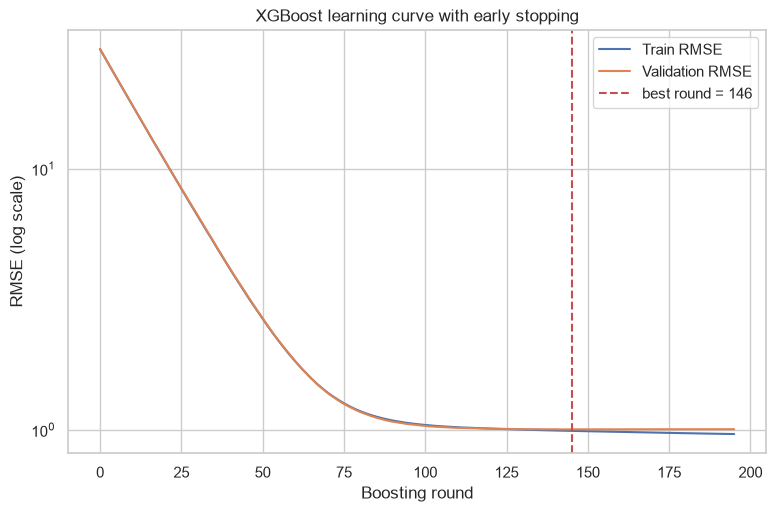

In [15]:
X_tr_raw, X_val_raw, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE)

prep_es = make_preprocessor(scale=False).fit(X_tr_raw)
X_tr_t, X_val_t = prep_es.transform(X_tr_raw), prep_es.transform(X_val_raw)

xgb_es = XGBRegressor(n_estimators=2000, learning_rate=0.05, max_depth=4,
subsample=0.8, colsample_bytree=0.8, tree_method="hist",early_stopping_rounds=50, eval_metric="rmse",random_state=RANDOM_STATE, n_jobs=-1)
xgb_es.fit(X_tr_t, y_tr, eval_set=[(X_tr_t, y_tr), (X_val_t, y_val)], verbose=False)

best_iter = int(xgb_es.best_iteration) + 1
history = xgb_es.evals_result()
print(f"Best number of trees (early stopping): {best_iter}")
print(f"Validation RMSE at best iteration     : {history['validation_1']['rmse'][best_iter - 1]:.4f}")

plt.figure(figsize=(9, 5.5))
plt.plot(history["validation_0"]["rmse"], label="Train RMSE")
plt.plot(history["validation_1"]["rmse"], label="Validation RMSE")
plt.axvline(best_iter - 1, color="r", ls="--", label=f"best round = {best_iter}")
plt.yscale("log")
plt.xlabel("Boosting round")
plt.ylabel("RMSE (log scale)")
plt.title("XGBoost learning curve with early stopping")
plt.legend()
plt.show()

## Hyper Parameter tuning 

A randomised search smaples 30 random combinations and scores each with 5-fold-cross-validation on the training set(150 model fits). It is much cheaper than a full grid and works well for boosting.

In [16]:
xgb_pipe = Pipeline([
    ("prep", make_preprocessor(scale=False)),
    ("model", XGBRegressor(tree_method="hist", objective="reg:squarederror",
    importance_type="gain", random_state=RANDOM_STATE, n_jobs=1)),
])

param_dist = {
    "model__n_estimators": randint(200, 900),
    "model__learning_rate": uniform(0.02, 0.18),
    "model__max_depth": randint(2, 7),
    "model__min_child_weight": randint(1, 10),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__gamma": uniform(0, 1),
    "model__reg_alpha": uniform(0, 1),
    "model__reg_lambda": uniform(0.5, 4.5),
}

search = RandomizedSearchCV(xgb_pipe, param_dist, n_iter=30, cv=cv,scoring="neg_root_mean_squared_error",
random_state=RANDOM_STATE, n_jobs=-1, refit=True,
return_train_score=True, verbose=1)
search.fit(X_train, y_train)

print(f"\nBest CV RMSE: {-search.best_score_:.4f}")
print("Best parameters:")
for k, v in search.best_params_.items():
    print(f"  {k.replace('model__', ''):18s} {v:.4f}" if isinstance(v, float) else f"  {k.replace('model__', ''):18s} {v}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV RMSE: 1.0408
Best parameters:
  colsample_bytree   0.9762
  gamma              0.9539
  learning_rate      0.1847
  max_depth          4
  min_child_weight   9
  n_estimators       236
  reg_alpha          0.9283
  reg_lambda         2.4268
  subsample          0.9867


In [17]:
top_trials = (pd.DataFrame(search.cv_results_).sort_values("rank_test_score").head(8)[["rank_test_score", "mean_test_score", "std_test_score", "mean_train_score","param_model__n_estimators", "param_model__learning_rate", "param_model__max_depth"]])
top_trials["mean_test_score"] = -top_trials["mean_test_score"]
top_trials["mean_train_score"] = -top_trials["mean_train_score"]
top_trials.rename(columns={"mean_test_score": "val_RMSE", "mean_train_score": "train_RMSE",
"std_test_score": "val_RMSE_std"})

,rank_test_score,val_RMSE,val_RMSE_std,train_RMSE,param_model__n_estimators,param_model__learning_rate,param_model__max_depth
29,1,1.0408,0.0154,0.9786,236,0.1847,4
7,2,1.0463,0.0159,0.8979,252,0.0281,6
3,3,1.0465,0.0184,0.9090,443,0.0363,4
24,4,1.0517,0.0143,0.8873,303,0.0351,5
25,5,1.0539,0.0182,0.9940,362,0.0489,3
22,6,1.0544,0.0188,1.0089,771,0.0611,3
6,7,1.0691,0.0208,0.9044,401,0.1945,3
19,8,1.0704,0.0266,0.8920,710,0.1047,3


## Final model: errors and diagnostics

In [18]:
best_xgb = search.best_estimator_
results = pd.concat([error_table(lin_pipe, "Linear Regression", n_feat),error_table(xgb_default, "XGBoost (default-ish)", n_feat),
error_table(best_xgb, "XGBoost (tuned)", n_feat)], ignore_index=True)
results

,Model,Dataset,MAE,MSE,RMSE,R2,Adj_R2,MAPE_%
0,Linear Regression,Train,0.7748,1.0232,1.0115,0.9989,0.9989,1.3941
1,Linear Regression,Test,0.7956,1.1118,1.0544,0.9988,0.9987,1.3870
2,XGBoost (default-ish),Train,0.6634,0.7368,0.8584,0.9992,0.9992,1.2305
3,XGBoost (default-ish),Test,0.8326,1.2184,1.1038,0.9986,0.9986,1.4489
4,XGBoost (tuned),Train,0.7584,0.9822,0.9910,0.9989,0.9989,1.3710
5,XGBoost (tuned),Test,0.8196,1.1821,1.0873,0.9987,0.9987,1.4217


In [19]:
cv_report(best_xgb, "XGBoost (tuned)")

5-fold cross-validation on the training set - XGBoost (tuned)


,Metric,CV train (mean),CV validation (mean),CV validation (std)
0,MAE,0.7520,0.7955,0.0098
1,RMSE,0.9786,1.0408,0.0154
2,R2,0.9989,0.9988,0.0000


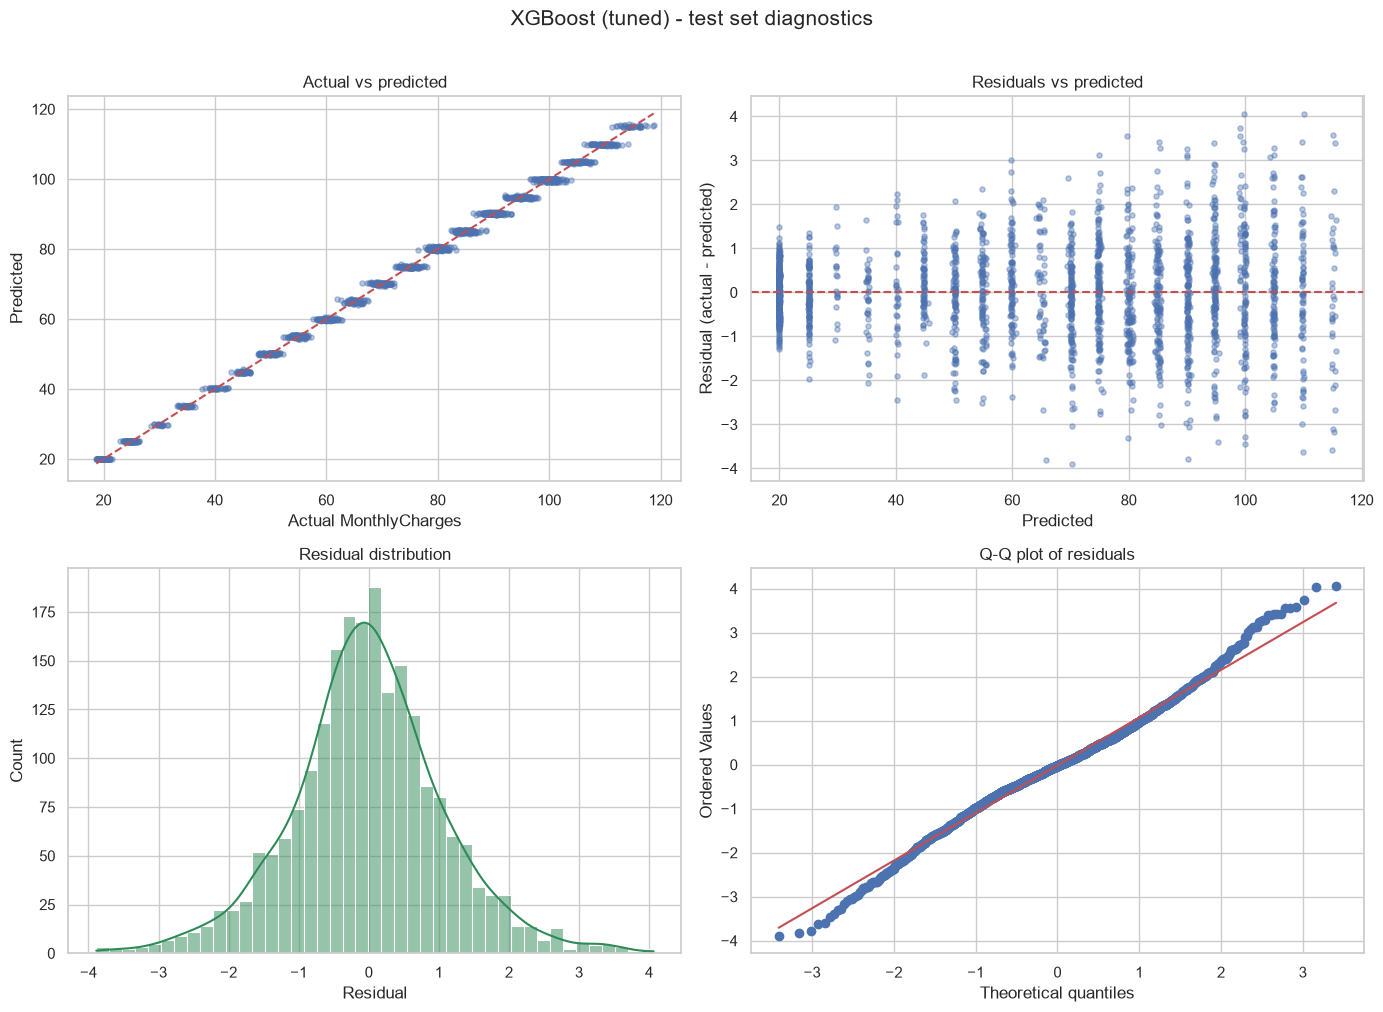

In [20]:
diagnostic_plots(y_test, best_xgb.predict(X_test), "XGBoost (tuned) - test set diagnostics")

In [21]:
worst_predictions(best_xgb, X_test, y_test, n=10)

,actual,predicted,abs_error,InternetService,Contract,num_addons,tenure
5190,103.9500,99.8852,4.0648,Fiber optic,Month-to-month,3,29
3856,114.1000,110.0563,4.0437,Fiber optic,Month-to-month,5,61
1844,66.4000,70.2885,3.8885,DSL,One year,4,59
6754,61.9000,65.7185,3.8185,DSL,Two year,3,0
4715,86.4000,90.1855,3.7855,DSL,Two year,6,64
7034,102.9500,99.2030,3.7470,Fiber optic,Month-to-month,4,67
5478,106.3000,109.9322,3.6322,Fiber optic,Two year,6,52
6859,111.3000,114.8898,3.5898,Fiber optic,Two year,6,71
2115,118.6500,115.0635,3.5865,Fiber optic,Two year,6,71
5737,83.2500,79.6968,3.5532,DSL,Month-to-month,5,18


## Feature importance

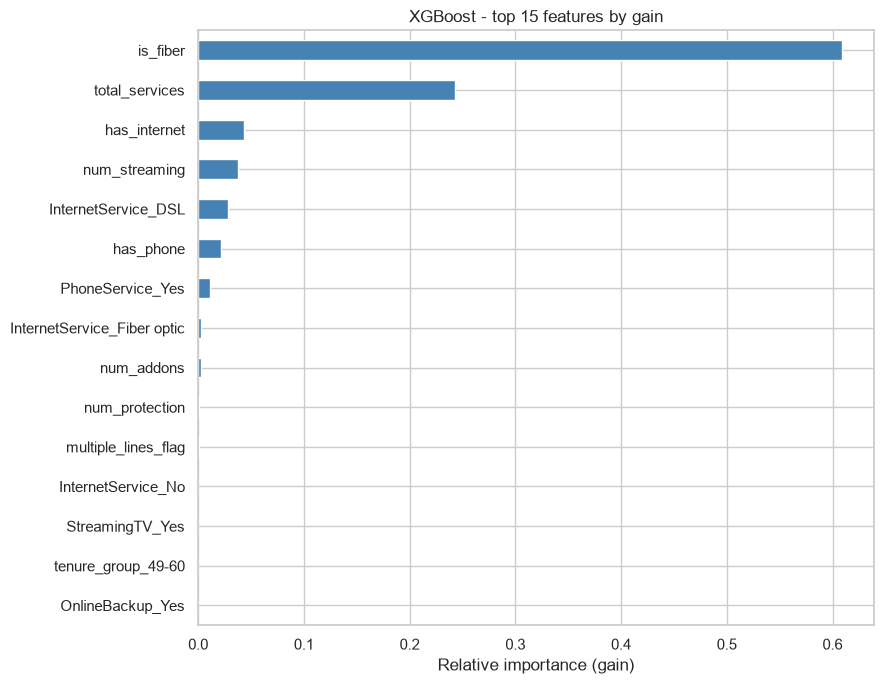

In [22]:
fnames = clean_names(best_xgb.named_steps["prep"].get_feature_names_out())
gain = pd.Series(best_xgb.named_steps["model"].feature_importances_, index=fnames).sort_values()

plt.figure(figsize=(9, 7))
gain.tail(15).plot.barh(color="steelblue")
plt.title("XGBoost - top 15 features by gain")
plt.xlabel("Relative importance (gain)")
plt.tight_layout()
plt.show()

,feature,rmse_increase,std
22,is_fiber,21.5366,0.2937
25,total_services,18.9413,0.2317
21,has_internet,6.0775,0.0746
19,num_streaming,4.7340,0.0838
23,has_phone,3.6452,0.0621
24,multiple_lines_flag,0.3834,0.0208
7,InternetService,0.3454,0.0123
18,num_addons,0.1487,0.0092
20,num_protection,0.0826,0.0060
5,PhoneService,0.0556,0.0035


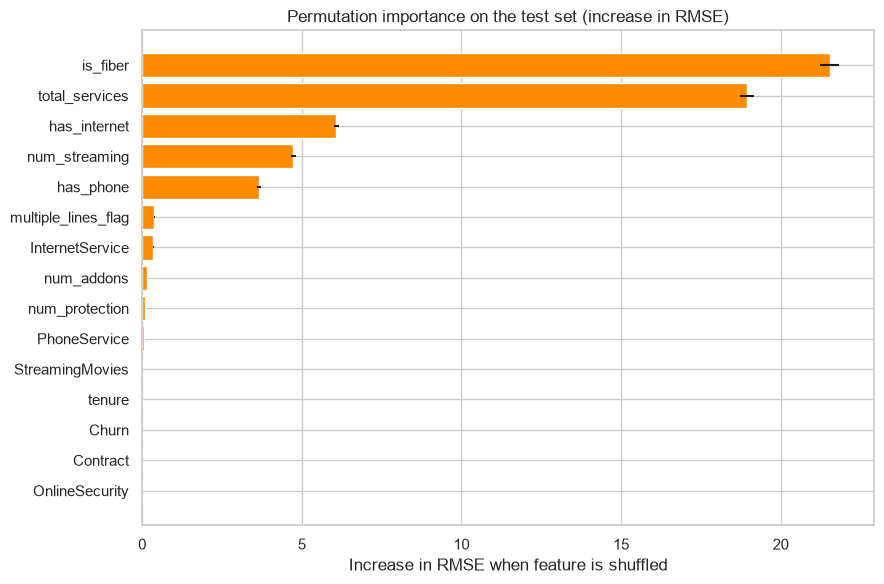

In [23]:
perm = permutation_importance(best_xgb, X_test, y_test, n_repeats=10,scoring="neg_root_mean_squared_error",random_state=RANDOM_STATE, n_jobs=-1)
perm_df = (pd.DataFrame({"feature": X_test.columns,
"rmse_increase": perm.importances_mean,
"std": perm.importances_std})
.sort_values("rmse_increase", ascending=False))
display(perm_df.head(15))

top = perm_df.head(15).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top["feature"], top["rmse_increase"], xerr=top["std"], color="darkorange")
plt.title("Permutation importance on the test set (increase in RMSE)")
plt.xlabel("Increase in RMSE when feature is shuffled")
plt.tight_layout()
plt.show()